# Identificação de dígitos através de características extraídas de sinais de áudio

## Alunos
- Vasco Alves - nº estudante 2022228207

## Introdução
Este projeto teve como âmbito analisar gravações de áudio com o objetivo de identificar os dígitos a serem pronunciados.
Para este efeito, foram elaboradas, implementadas vários conjuntos de _features_ temporais e _features_ espectrais. Adicionalmente, foi feito um pré-processamento dos dados antes para evitar, por exemplo, o tom da voz, ou a pronúncia do sujeito de influenciar os resultados.


Os dados compreendem um total de 30000 gravações: cinquenta gravações por dígito por cada um dos sessenta indivíduos. Os dados estão organizados por indivíduo. O áudio foi capturado quarenta e oito mil vezes por segundo ($48000\text{ Hz}$), em modo mono-canal e armazenado no formato _lossless_ _Waveform_ (extensão de ficheiro '_.wav_'). 

Feito esta introdução, podemos prosseguir com a análise dos resultados.


# Meta 1 Análise Temporal e de Frequência 

## Importação dos Dados (Ex. 1)


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy
from scipy.io import wavfile
import scipy.io as sio
import os
import random

"""
Crie uma estrutura de dados (por exemplo, uma tabela) e guarde as seguintes informações relativas a cada áudio: 

- a. diretório do áudio; 
- b. nome do ficheiro (com extensão); 
- c. participante; 
- d. dígito; 
- e. número da repetição. 
"""

#a pasta 'data' deve estar na mesma pasta que o notebook
pastas = [d for d in os.listdir('data') if os.path.isdir(os.path.join('data', d))]
mega_dados_xpto = []
for p in pastas:
    caminho_pasta = os.path.join('data', p)
    # ficheiros .wav dentro de cada pasta de participante
    ficheiros = [f for f in os.listdir(caminho_pasta) if f.endswith('.wav')]
    for f in ficheiros:
        # nome do ficheiro: -> digito_participante_repeticao.wav 
        # removemos a extensão .wav e dividimos pelo underscore
        # para obter os dados
        nome_sem_extensao = f.replace('.wav', '')
        partes = nome_sem_extensao.split('_')
        if len(partes) == 3:
            digito, participante, repeticao = partes
            mega_dados_xpto.append([p, f, int(participante), int(digito), int(repeticao)])

# Eu gosto de DataFrames
cols = ["dir", "nome", "participante", "digito", "repeticao"]
dados_df = pd.DataFrame(mega_dados_xpto, columns=cols)

# Se o número de registos não for 30000, está errado
assert(len(dados_df) == 60 * 50 * 10)
print(f"Total de registos: {len(dados_df)}")
print(dados_df.head())


# NOTA: Comentar para usar os dados completos
dados_df = dados_df[dados_df['participante'] == 1]

Total de registos: 30000
  dir         nome  participante  digito  repeticao
0  01   0_01_0.wav             1       0          0
1  01   0_01_1.wav             1       0          1
2  01  0_01_10.wav             1       0         10
3  01  0_01_11.wav             1       0         11
4  01  0_01_12.wav             1       0         12


## Exercicio 2
Desenvolva código para importação dos sinais de áudio e guarde o valor da taxa de amostragem e os sinais na estrutura de dados criada no ponto 1. Nota: pode utilizar a função audioread do MATLAB. 

In [58]:
# novas colunas vazias
dados_df['signal'] = None
dados_df['sampling_rate'] = None
for idx, row in dados_df.iterrows():
    caminho_completo = os.path.join('data', row['dir'], row['nome'])  
    try:
        sr, signal = wavfile.read(caminho_completo)
        dados_df.at[idx, 'signal'] = signal
        dados_df.at[idx, 'sampling_rate'] = sr      
    except Exception as e:
        print(f"wav não existe?? - {caminho_completo} - {e}")
print("Colunas adicionadas com sucesso!")
print(dados_df[['nome', 'sampling_rate']].head())

Colunas adicionadas com sucesso!
          nome sampling_rate
0   0_01_0.wav         48000
1   0_01_1.wav         48000
2  0_01_10.wav         48000
3  0_01_11.wav         48000
4  0_01_12.wav         48000


## Representação Gráfica dos Sinais (Ex. 3)
O código seguinte seleciona aleatoriamente um participante e uma repetição, gerando uma grelha de subplots para os dígitos de 0 a 9. O eixo horizontal é convertido de amostras para segundos através da taxa de amostragem.

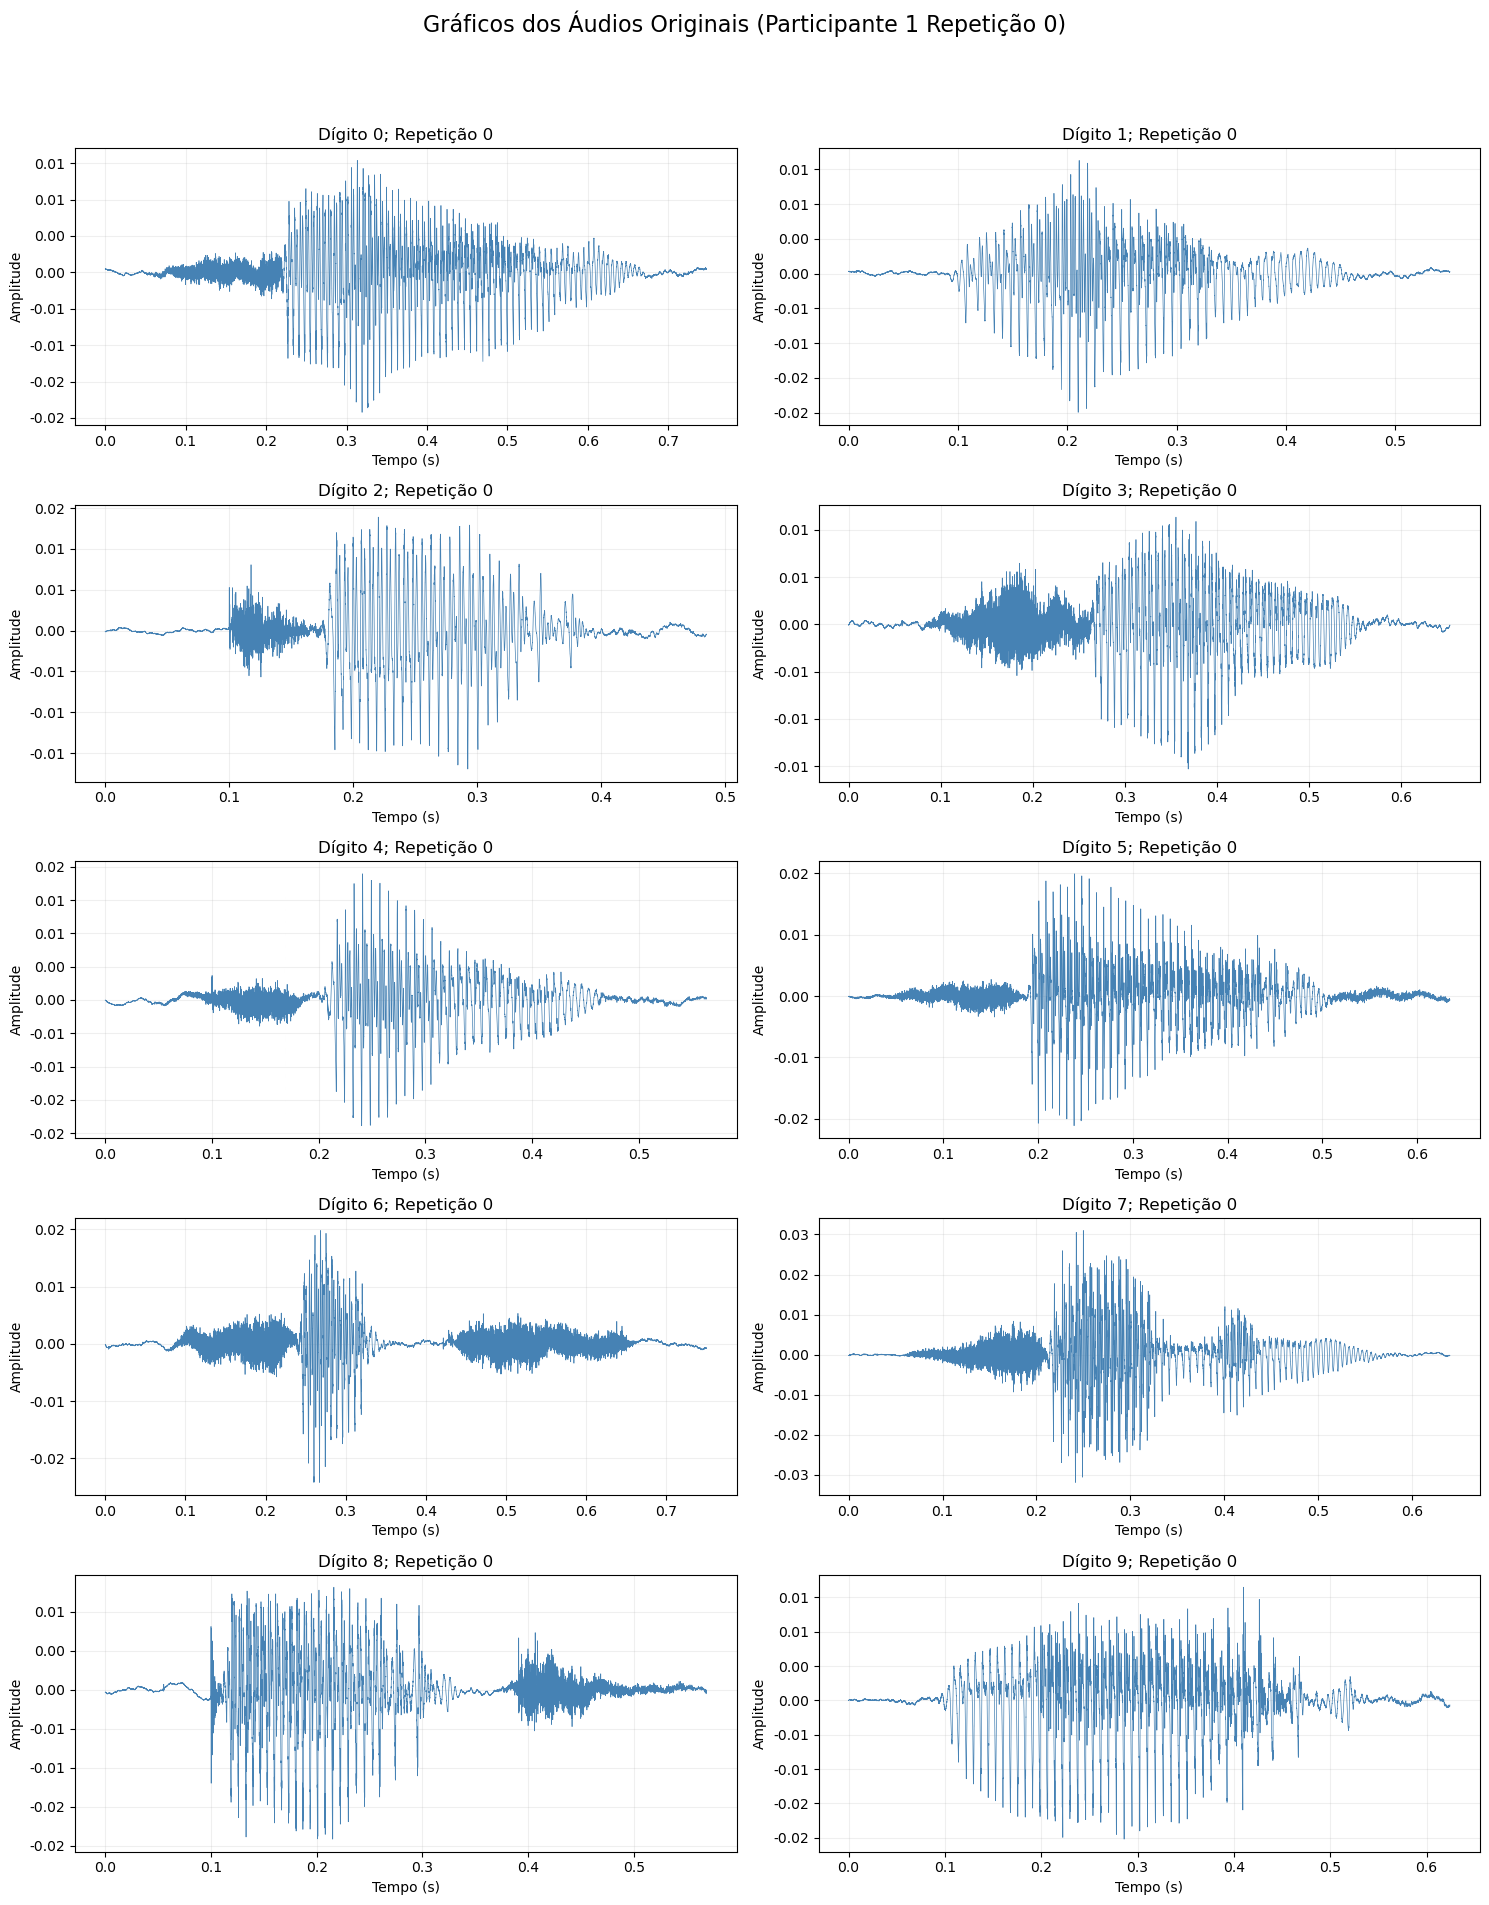

In [59]:
from matplotlib.ticker import FormatStrFormatter
# escolher um participante e uma repeticao aleatoriamente
sujeito_aleatorio = random.choice(dados_df['participante'].unique())
rep_aleatoria = random.choice(dados_df['repeticao'].unique())

# criar a figura com 5 linhas e 2 colunas
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle(f'Gráficos dos Áudios Originais (Participante {sujeito_aleatorio} Repetição {rep_aleatoria})', fontsize=16)

# iterar pelos digitos de 0 a 9
for digito in range(10):
    selecao = dados_df[(dados_df['participante'] == sujeito_aleatorio) & 
                      (dados_df['repeticao'] == rep_aleatoria) & 
                      (dados_df['digito'] == digito)]
    
    if not selecao.empty:
        # NOTE(vasco): o formato wav vem em inteiros de 16 bits
        # é necessario converter para floats para ficar
        # como está na figura
        sinal = selecao.iloc[0]['signal'] / pow(2, 15) # 15 porque sao inteiros positivos
        sr = selecao.iloc[0]['sampling_rate']
        
        # calcular o vetor de tempo em segundos
        tempo = np.linspace(0, len(sinal) / sr, num=len(sinal))
        ax = axes[digito // 2, digito % 2]
        
        # plot do sinal
        ax.plot(tempo, sinal, color='steelblue', linewidth=0.5)
        ax.set_title(f'Dígito {digito}; Repetição {rep_aleatoria}')
        ax.set_xlabel('Tempo (s)')
        ax.set_ylabel('Amplitude')
        # eu queria que fosse exatamente igual à imagem!!!
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.grid(alpha=0.2)

# ajustar o layout para nao sobrepor titulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Préprocessamento (Ex 4)
Para faciliar a análise dos dados, foi feita a normalização do audio. Adicionalmente, removemos o ruido inicial e final do ficheiro; adicionamos silencio para garantir que todos tem os ficheiros de audio tem duração igual. 


In [60]:
dados_df['signal_preproc'] = None
duracao_ideal = 0.5 # duraçao ideal de meio segundo (arbitrario)


for idx, row in dados_df.iterrows():
    # z score / signal normalizado e outliers wow
    s, sr = row['signal'], row['sampling_rate']
    Z = ( s - np.mean(s) ) / np.std(s)
    outliers = np.abs(Z) > 1
    start = np.argmax(outliers)
    end = outliers.size - np.argmax(outliers[::-1])

    s_cortado = Z[start:end]
    n_amostras_alvo = int(duracao_ideal * sr)
    
    if len(s_cortado) > n_amostras_alvo:
        # se for maior, corta o fim
        s_final = s_cortado[:n_amostras_alvo]
    else:
        # se for menor, adiciona zeros no fim
        s_final = np.pad(s_cortado, (0, n_amostras_alvo - len(s_cortado)), 'constant')
    
    dados_df.at[idx, 'signal_preproc'] = s_final

print(dados_df)

    dir         nome  participante  digito  repeticao  \
0    01   0_01_0.wav             1       0          0   
1    01   0_01_1.wav             1       0          1   
2    01  0_01_10.wav             1       0         10   
3    01  0_01_11.wav             1       0         11   
4    01  0_01_12.wav             1       0         12   
..   ..          ...           ...     ...        ...   
495  01   9_01_5.wav             1       9          5   
496  01   9_01_6.wav             1       9          6   
497  01   9_01_7.wav             1       9          7   
498  01   9_01_8.wav             1       9          8   
499  01   9_01_9.wav             1       9          9   

                                                signal sampling_rate  \
0    [15, 14, 15, 15, 14, 15, 15, 14, 14, 14, 14, 1...         48000   
1    [2, 2, 2, 2, 3, 3, 3, 2, 2, 3, 3, 3, 2, 3, 3, ...         48000   
2    [-13, -13, -13, -13, -12, -12, -12, -12, -12, ...         48000   
3    [-7, -7, -7, -6, -6, -

## Visualização dos Sinais Após o Preprocessamento (Ex. 5)

O gráfico anterior foi recriada para os sinais processados.

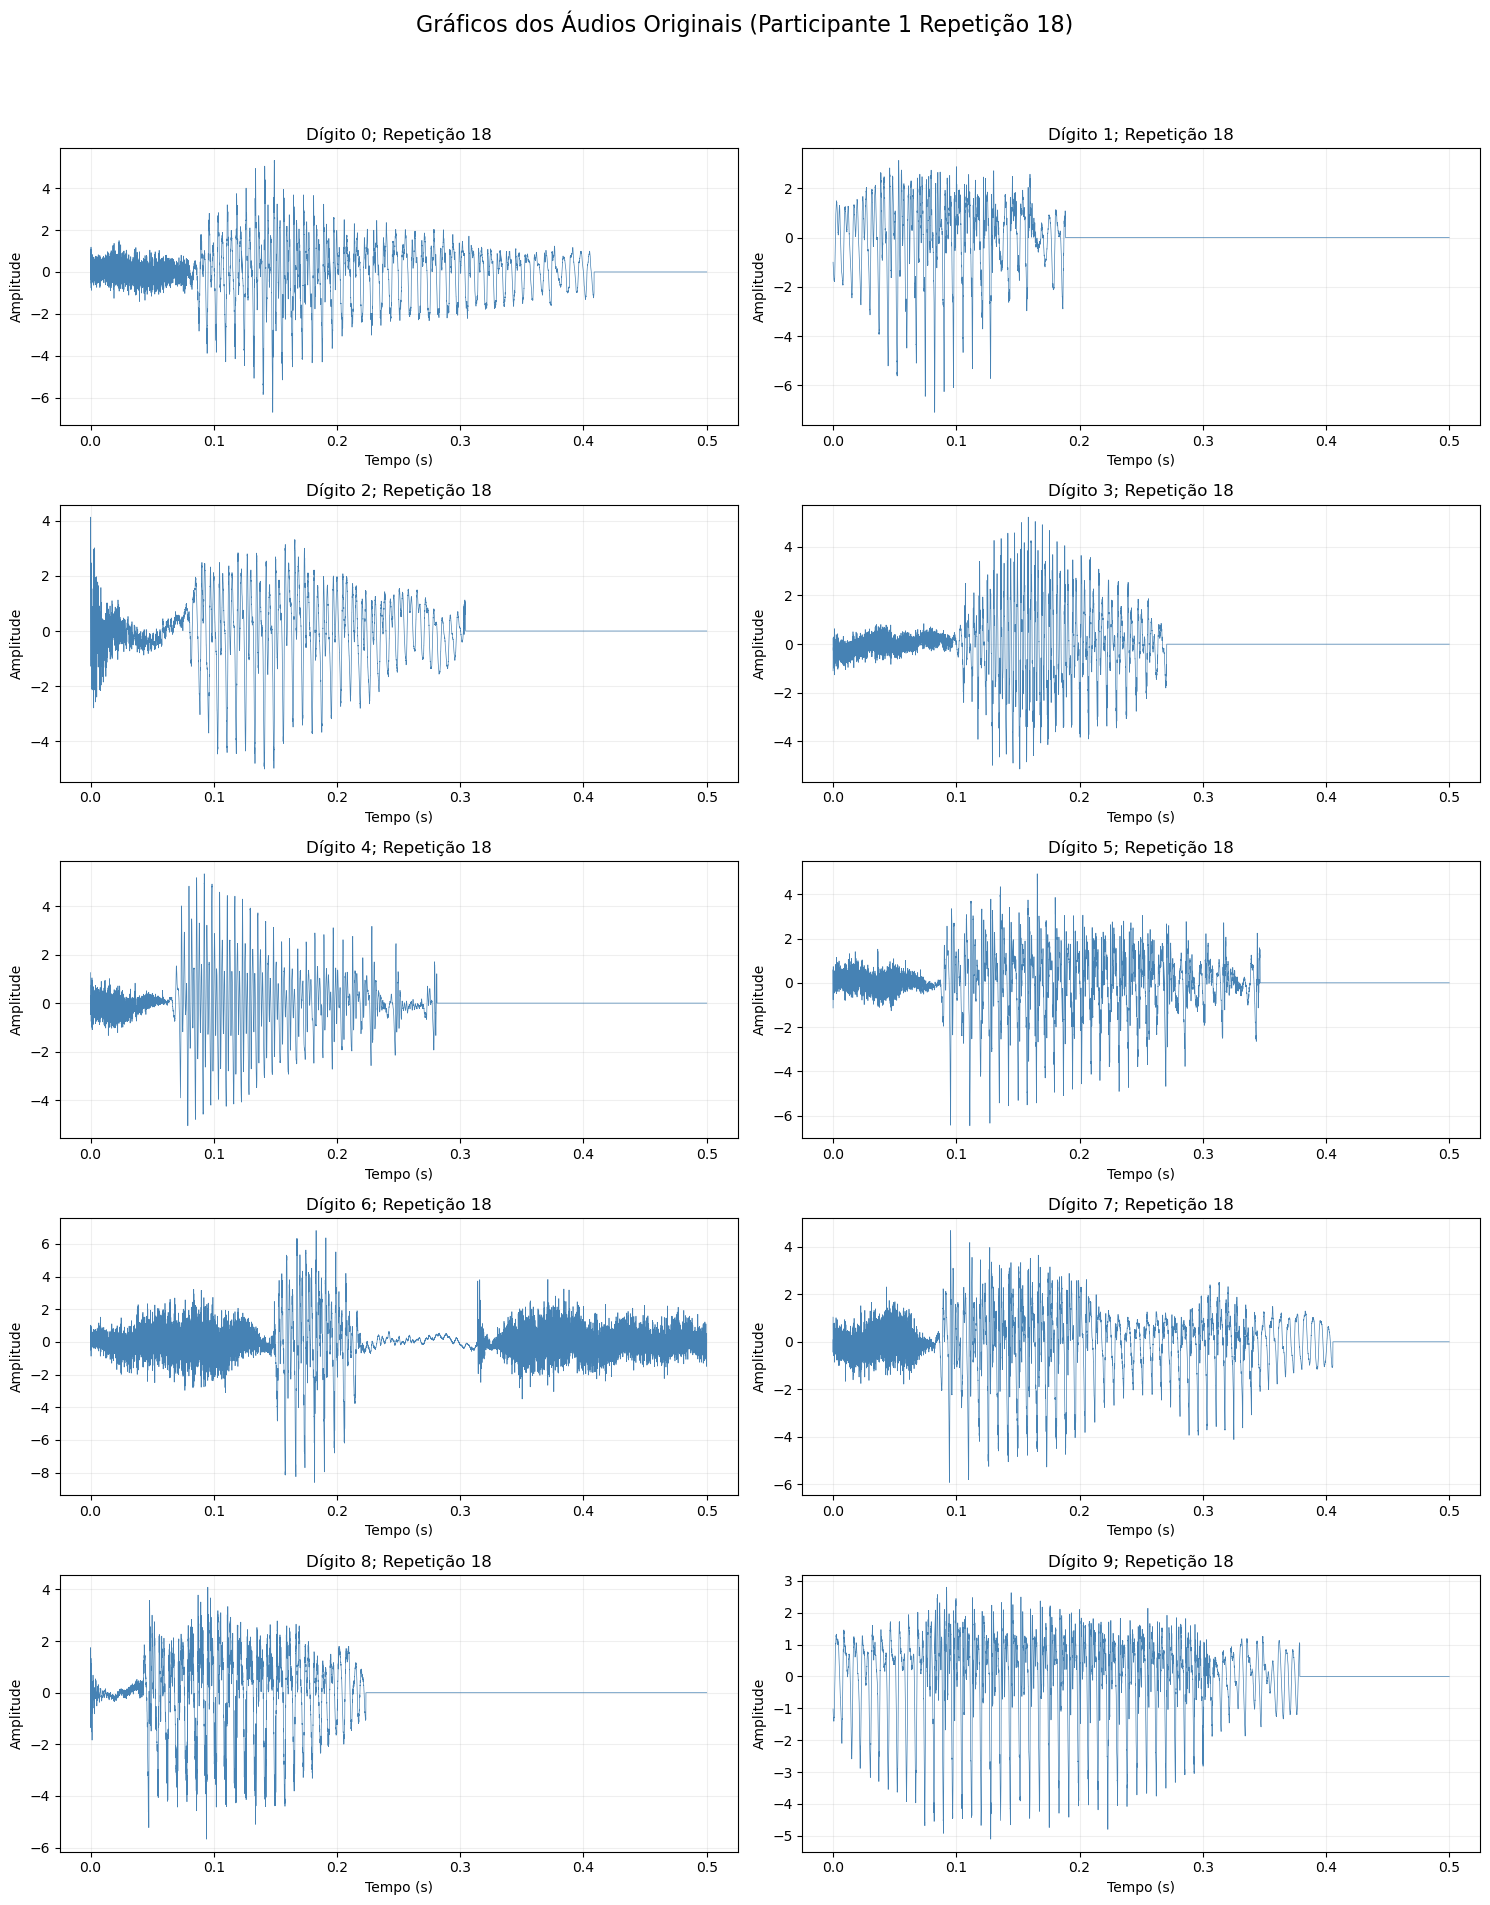

In [61]:
from matplotlib.ticker import FormatStrFormatter
# escolher um participante e uma repeticao aleatoriamente
sujeito_aleatorio = random.choice(dados_df['participante'].unique())
rep_aleatoria = random.choice(dados_df['repeticao'].unique())

# criar a figura com 5 linhas e 2 colunas
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle(f'Gráficos dos Áudios Originais (Participante {sujeito_aleatorio} Repetição {rep_aleatoria})', fontsize=16)

# iterar pelos digitos de 0 a 9
for digito in range(10):
    selecao = dados_df[(dados_df['participante'] == sujeito_aleatorio) & 
                      (dados_df['repeticao'] == rep_aleatoria) & 
                      (dados_df['digito'] == digito)]
    
    if not selecao.empty:
        # NOTE(vasco): já foi normalizado, não é necessário dividir        
        sinal = selecao.iloc[0]['signal_preproc']
        sr = selecao.iloc[0]['sampling_rate']
        
        # calcular o vetor de tempo em segundos
        tempo = np.linspace(0, len(sinal) / sr, num=len(sinal))
        ax = axes[digito // 2, digito % 2]
        
        # plot do sinal
        ax.plot(tempo, sinal, color='steelblue', linewidth=0.5)
        ax.set_title(f'Dígito {digito}; Repetição {rep_aleatoria}')
        ax.set_xlabel('Tempo (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(alpha=0.2)

# ajustar o layout para nao sobrepor titulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Possíveis _features_ temporais para a extração de digitos (Ex. 6)

Enquanto o gráfico no ponto 3 contém os sinais brutos, onde a escala é específica do formato do áudio, o gráfico do ponto 5 contém os sinais processados, normalizados e sem o ruído inicial, onde a escala é normal (1 = desvio padrão). Esta contraposição expõe a morfologia temporal dos dados.

### Decomposição em Fonemas

Os dígitos podem vir a ser identificados pela sua "decomposição em blocos". Isto é, podemos observar que digitos são constituídos por uma ou mais "ondas" distintas onde existe uma concentração de energia, as quais podemos assumir terem algum significado fonético — por exemplo, uma sílaba — mas não necessariamente. Pode ser mais adequado o termo "som" ou "fonema", pois, embora _three_ seja um monossílabo, podemos observar visualmente que o sinal é decomposto nos sons _th_ (consoante fricativa) e _ree_.

Sabendo identificar o número e o tipo de fonemas, sabemos também identificar os digitos.
Ou seja, para além de _features_ genéricas adequadas ao estudo de áudio geral, vamos querer identificar _features_ que são especificamente adequadas a análise de padrões de fala humana.

### Short-term Energy (Energia de Curto Prazo)

Surge naturalmente a energia de curto prazo como a ferramenta indicada para fazer a separação de fonemas.
Esta característica consiste no cálculo da soma das amostras ao quadrado (o quadrado das amostras e depois a soma). Ao observar a evolução da energia de curto prazo, conseguimos identificar "vales" que separam os fonemas em dígitos dissilábicos (como o "ze-ro" ou "ni-ne"), permitindo distinguir a cadência rítmica de cada número. No mínimo permite distinguir entre dígitos monossilábicos e dissilábicos.


### Long-term Energy (Energia de Longo Prazo)

Ao contrário da anterior, esta métrica condensa a energia de todo o sinal após a normalização. Digitos mais foneticamente "carregados" como "four" e "seven" vão ter mais energia total do que digitos mais leves. Para além de contribuir para a separação de dígitos monossilábicos de dissilábicos, entre os dígitos monossilábicos e dissilábicos distingue os mais carregados dos menos carregados.

### Zero Crossing Rate

Surge naturalmente o _Zero Crossing Rate_ como uma característica adequada para distinguir entre sons vocálicos (como o _-re_ em _three_) e sons fricativos (como o _th-_ em _three_). 

### Root Mean Square
Semelhante à energia de longo prazo, mas é menos sensível a picos extremos do que a energia de longo prazo. Digitos com consoantes mais acentuadas vão ser detetadas por esta _feature_.

### Duração Ativa

Embora todos os ficheiros tenham o mesmo comprimento após o pré-processamento, o padding extra de zeros é fácil de identificar e ignorar para o fim de obter a duração ativa do som. A duração ativa discrimina facilmente entre sons mais curtos (como "six") e sons mais longos (como "seven").


## Implementação da Extração de _Features_ (Ex. 7)
As _features_ temporais definidas anterior foram extraídas no codigo seguinte e armazenas em colunas respectivas.

In [62]:

def ShortTermEnergy(signal:np.ndarray):
    return np.sum(signal**2)

def LongTermEnergy(signal:np.ndarray):
    return np.sum(np.abs(signal))    
    
def ZeroCrossingRate(signal:np.ndarray):
    return np.sum(np.abs(np.diff(np.sign(signal)))) / (2 * len(signal))

def RootMeanSquare(signal:np.ndarray):
    return np.sqrt(np.mean(signal ** 2))

def DuracaoAtiva(signal:np.ndarray):
    # primeiro valor > 0 a contar do fim
    mascara = signal > 0
    idx = np.argmax(mascara[::-1])
    # cortar zeros
    signal_sem_padding = signal[0:idx]
    return len(signal_sem_padding) # podiamos dividir pelo sampling rate aqui
    


def ExtrairFeaturesTemporais(sinal):
    ecp = ShortTermEnergy(sinal)
    elp = LongTermEnergy(sinal)
    zcr = ZeroCrossingRate(sinal)
    rms = RootMeanSquare(sinal)
    da = DuracaoAtiva(sinal)
    return ecp, elp, zcr, rms, da

features = dados_df['signal_preproc'].apply(lambda x: ExtrairFeaturesTemporais(x))
cols_features = ['energia_curto', 'energia_longo', 'zcr', 'rms', 'duracao_ativa']
dados_df[cols_features] = pd.DataFrame(features.tolist(), index=dados_df.index)

print(dados_df.groupby('digito')[cols_features].mean())

        energia_curto  energia_longo       zcr       rms  duracao_ativa
digito                                                                 
0        32142.402054   17493.185170  0.053722  1.156127        5009.46
1        24198.843720   13277.863959  0.009104  1.003143       10730.54
2        24632.414194   13184.383226  0.021558  1.011892       10308.40
3        29401.482616   15558.137764  0.054484  1.105998        6899.38
4        28952.348628   14650.583366  0.056236  1.097402        7988.34
5        29910.989189   14834.083020  0.046693  1.113741        8743.96
6        34415.087109   15176.520924  0.162348  1.196134        1963.52
7        31652.599294   16845.396082  0.063835  1.147104        5350.46
8        27189.838337   13671.335248  0.026768  1.063421        8234.64
9        30603.219389   18220.915054  0.015878  1.128247        4817.42


## Representação Gráfica das _Features_ (Ex. 8)
Sendo que o RMS e a energia a curto e longo prazo são semelhantes na forma como são cálculadas, decidimos comparar cada uma com o ZCR e com a duração ativa para verificar qual era a melhor representação indidual de energia.

### ZCR vs. RMS/Energia a Curto/Longo Prazo vs. Duração Ativa

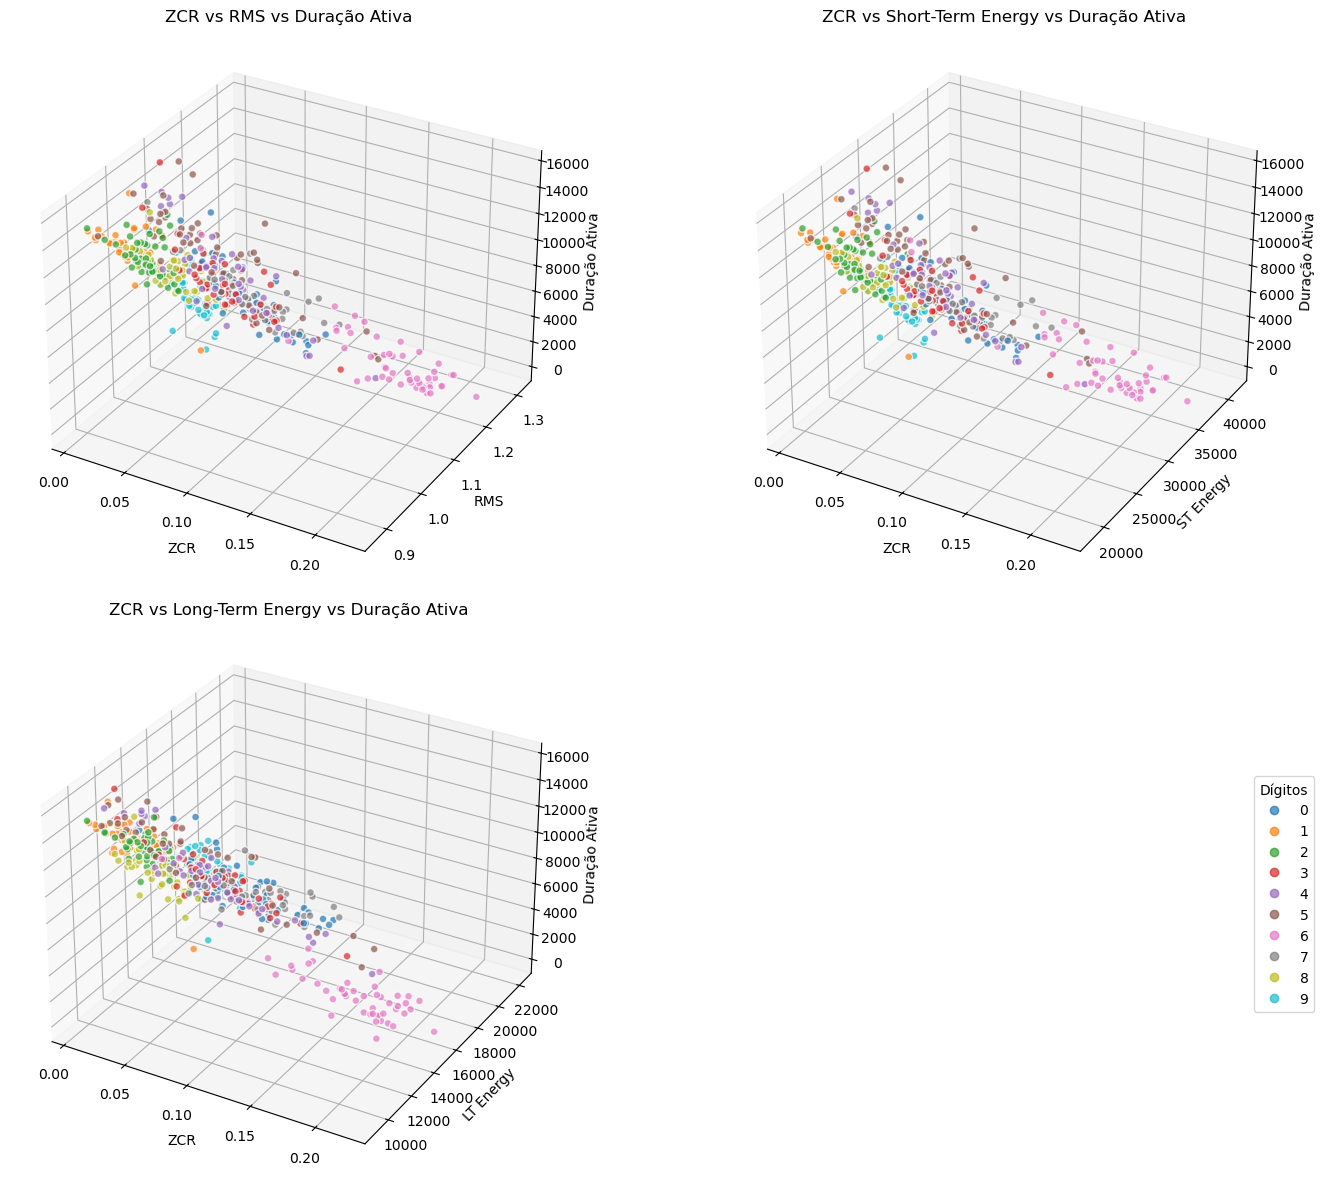

In [21]:
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure(figsize=(15,12))
classes=dados_df['digito']
ax1=fig.add_subplot(221,projection='3d')
sc1=ax1.scatter(dados_df['zcr'],dados_df['rms'],dados_df['duracao_ativa'],c=classes,cmap='tab10',s=30,alpha=0.7,edgecolors='w')
ax1.set_title('ZCR vs RMS vs Duração Ativa')
ax1.set_xlabel('ZCR')
ax1.set_ylabel('RMS')
ax1.set_zlabel('Duração Ativa')
ax2=fig.add_subplot(222,projection='3d')
sc2=ax2.scatter(dados_df['zcr'],dados_df['energia_curto'],dados_df['duracao_ativa'],c=classes,cmap='tab10',s=30,alpha=0.7,edgecolors='w')
ax2.set_title('ZCR vs Short-Term Energy vs Duração Ativa')
ax2.set_xlabel('ZCR')
ax2.set_ylabel('ST Energy')
ax2.set_zlabel('Duração Ativa')
ax3=fig.add_subplot(223,projection='3d')
sc3=ax3.scatter(dados_df['zcr'],dados_df['energia_longo'],dados_df['duracao_ativa'],c=classes,cmap='tab10',s=30,alpha=0.7,edgecolors='w')
ax3.set_title('ZCR vs Long-Term Energy vs Duração Ativa')
ax3.set_xlabel('ZCR')
ax3.set_ylabel('LT Energy')
ax3.set_zlabel('Duração Ativa')
fig.legend(*sc1.legend_elements(),loc='center right',title='Dígitos',bbox_to_anchor=(0.95,0.25))
plt.tight_layout()
plt.show()

### Enegia a Curto Prazo vs Energia a Longo Prazo vs RMS
Decidimos comparar estas três features para verificar se diferenciavam se entre si.


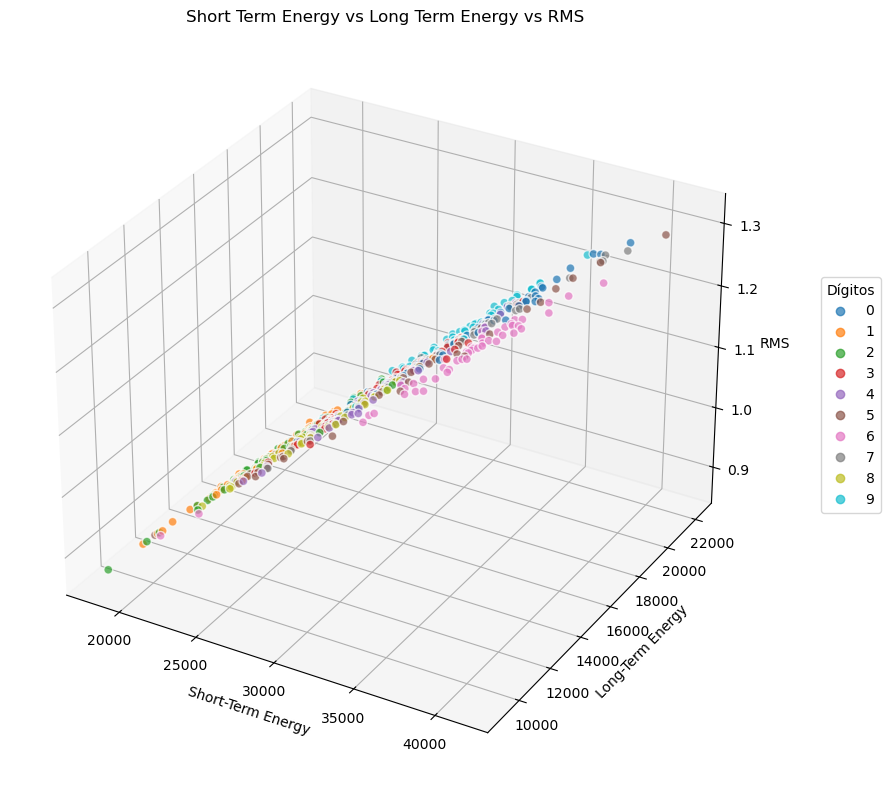

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')
classes=dados_df['digito']
sc=ax.scatter(dados_df['energia_curto'],dados_df['energia_longo'],dados_df['rms'],c=classes,cmap='tab10',s=40,alpha=0.7,edgecolors='w')
ax.set_title('Short Term Energy vs Long Term Energy vs RMS')
ax.set_xlabel('Short-Term Energy')
ax.set_ylabel('Long-Term Energy')
ax.set_zlabel('RMS')
fig.legend(*sc.legend_elements(),loc='center right',title='Dígitos')
plt.tight_layout()
plt.show()

O gráfico anterior indica que estas três _features_ são bastante semelhantes, e que poderia ser boa ideia adicionar uma nova _feature_, possivelmente substituindo uma delas.

### ZCR vs Duração Ativa

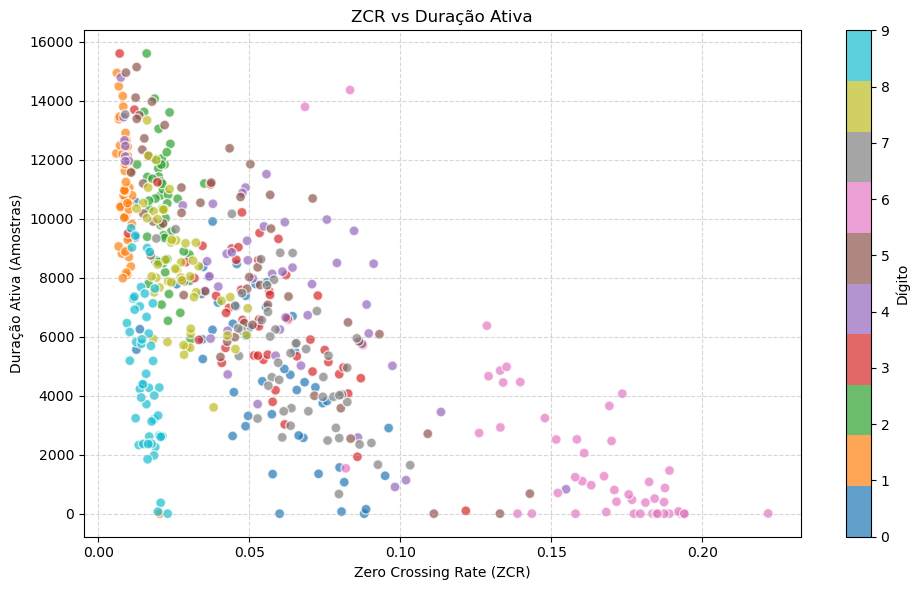

In [25]:
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(10,6))
ax=fig.add_subplot(111)
classes=dados_df['digito']
sc=ax.scatter(dados_df['zcr'],dados_df['duracao_ativa'],c=classes,cmap='tab10',s=50,alpha=0.7,edgecolors='w')
ax.set_title('ZCR vs Duração Ativa')
ax.set_xlabel('Zero Crossing Rate (ZCR)')
ax.set_ylabel('Duração Ativa (Amostras)')
ax.grid(True,linestyle='--',alpha=0.5)
plt.colorbar(sc,label='Dígito')
plt.tight_layout()
plt.show()

### As três melhores caracteriscicas

Podemos observar através do gráfico _Short Term Energy vs Long Term Energy vs RMS_ que estas _features_ têm pouca informação entre si, logo a melhor decisão é eliminar duas destas _features_. Ao analisar os três gráficos a comparar cada uma destas características contra o ZCR e contra a duração ativa, escolhi manter o RMS pois parece resultar na melhor separação.

Logo resta o ZCR, o RMS e a duração ativa.

## Coeficientes da Série Complexa de Fourier (Ex. 9)
Para cada sinal obtido após o pré-processamento, foi determinado os coeficientes da série complexa de 
Fourier e guardado na estrutura de dados. 

In [63]:
def SerieComplexaFourier(sinal):
    N = len(sinal)
    coeficientes = np.fft.fft(sinal) / N
    return coeficientes

dados_df['scf_coefs'] = dados_df['signal_preproc'].apply(SerieComplexaFourier)

# Visualizar a estrutura
print(dados_df[['digito', 'scf_coefs']].head())

   digito                                          scf_coefs
0       0  [(0.00194492375863994+0j), (0.0035501444751598...
1       0  [(0.004581677844897936+0j), (-0.00058554781412...
2       0  [(-0.003776426836272436+0j), (0.00091385718628...
3       0  [(-0.0005457912345198666+0j), (-0.000247525502...
4       0  [(-0.0022035737227944557+0j), (0.0014757533034...


## Espectro de Amplitude Mediano (Ex. 10)

Calcule, para cada dígito, o espectro de amplitude mediano, normalizado pelo número de amostras 
(i.e., equivalente ao módulo dos coeficientes da série complexa de Fourier), e somente para 
frequências positivas. Calcule também o primeiro quartil (25%) e terceiro quartil (75%). A Figura 
4 mostra um exemplo. Compare os gráficos obtidos.

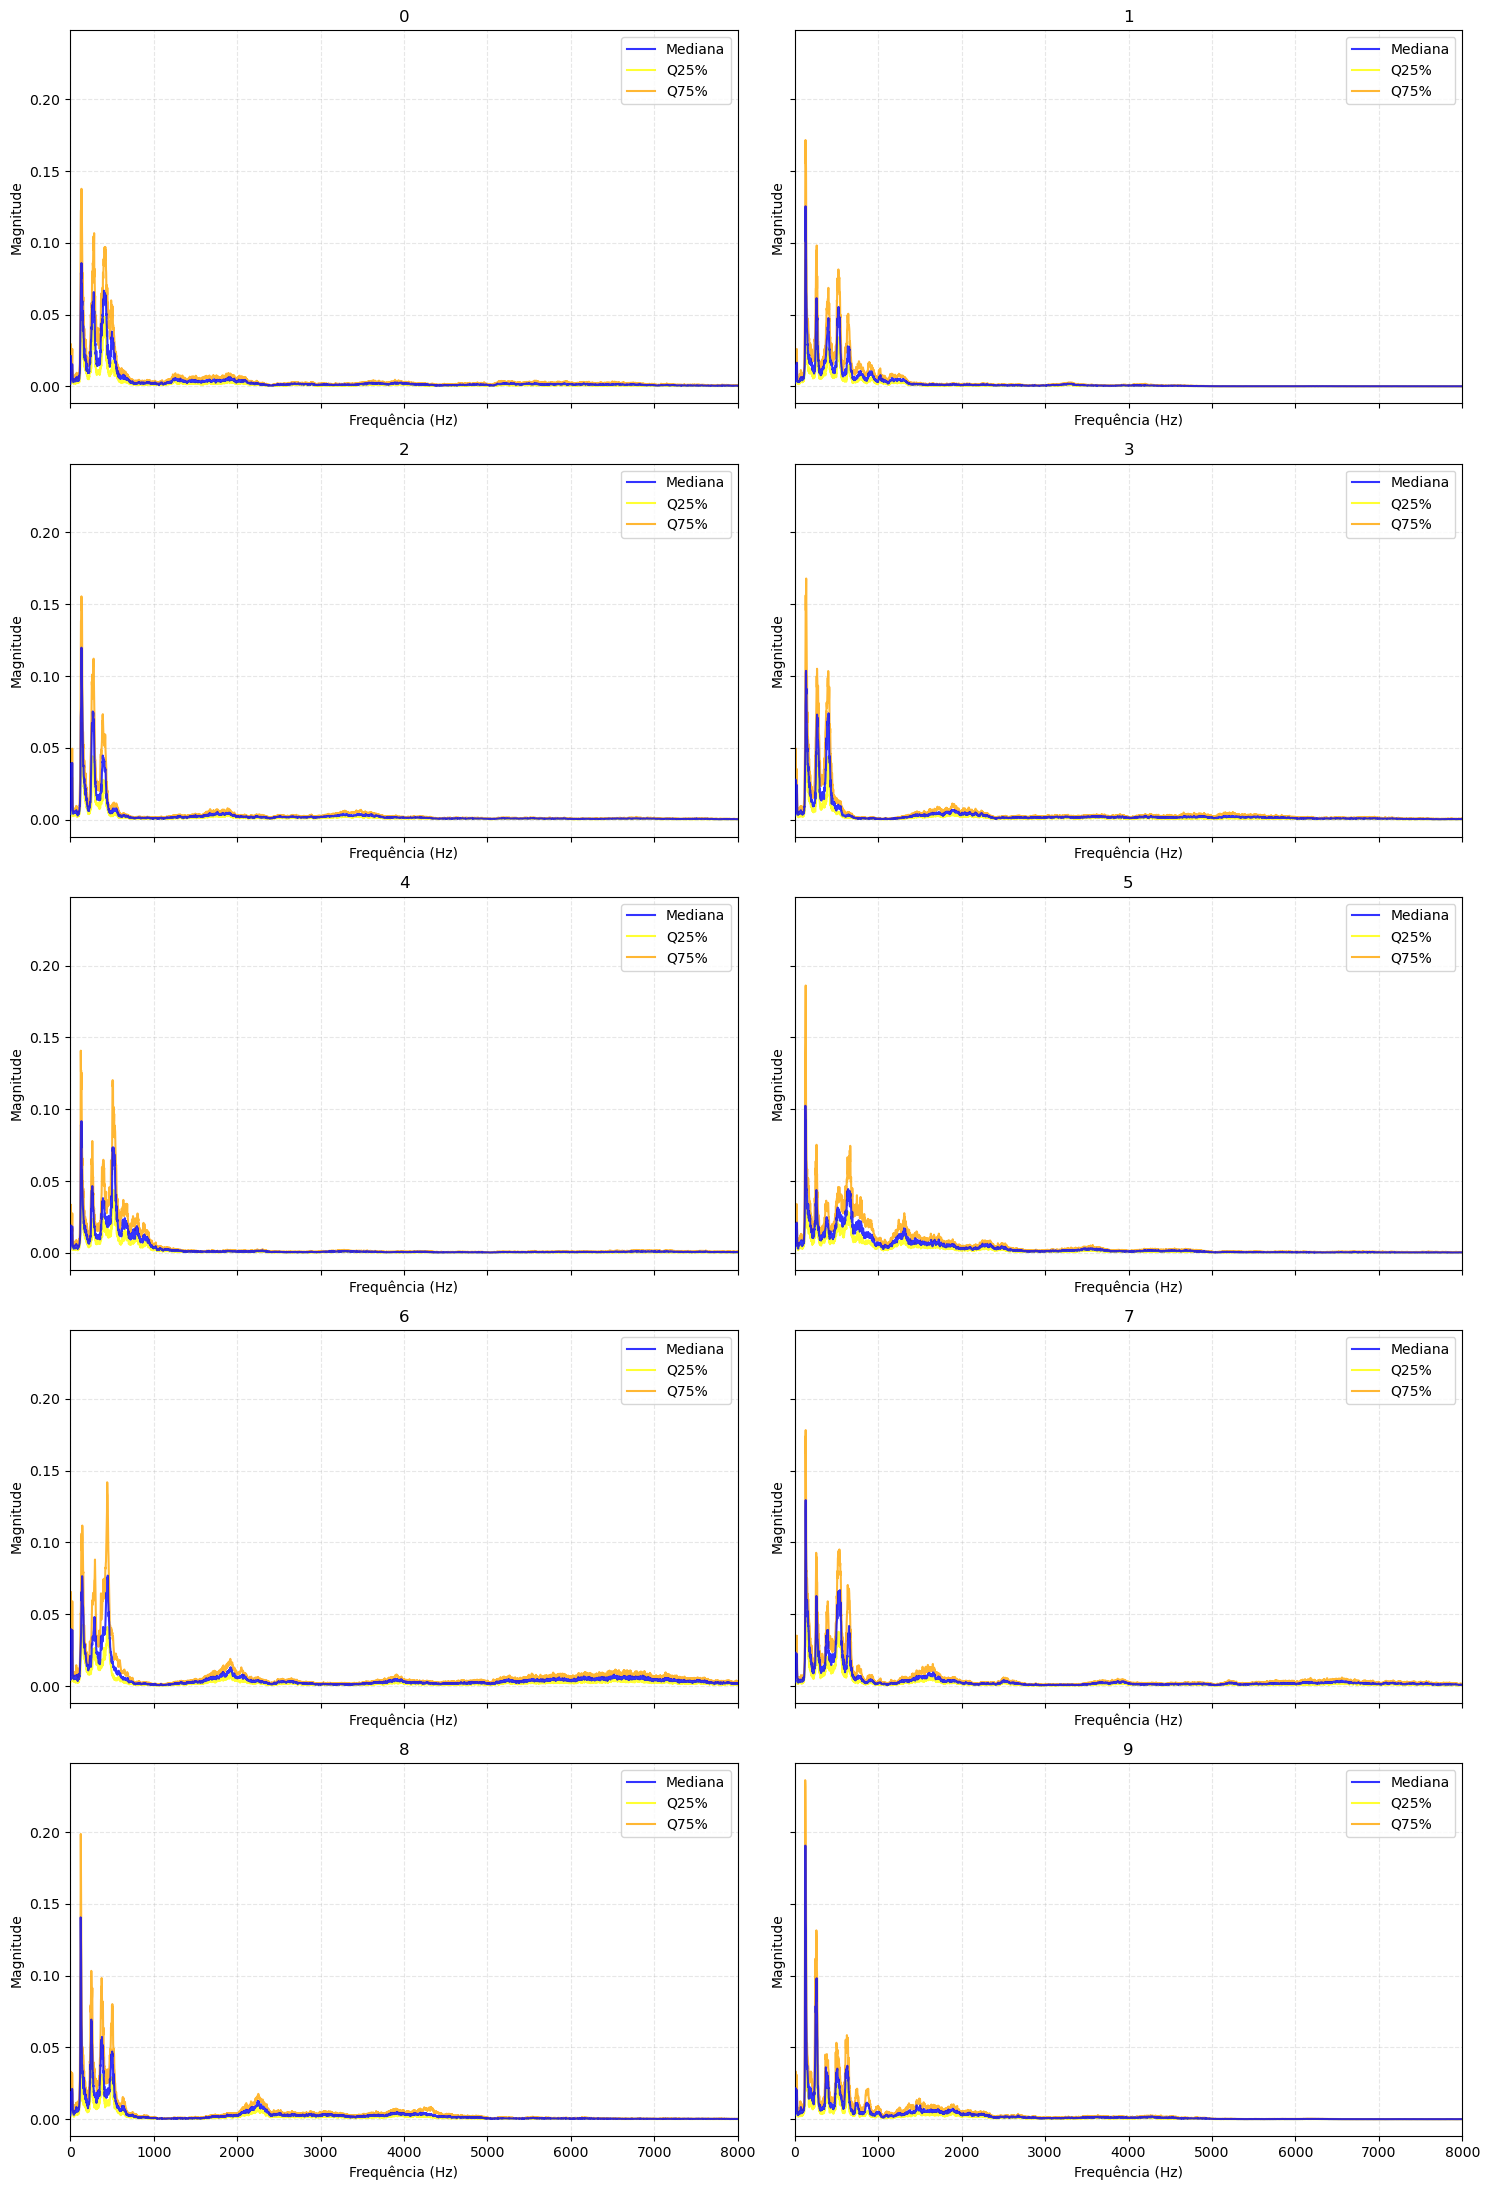

In [64]:
"""
Calcule, para cada dígito, o espectro de amplitude mediano, normalizado pelo número de amostras
(i.e., equivalente ao módulo dos coeficientes da série complexa de Fourier), e somente para
frequências positivas.

Calcule também o primeiro quartil (25%) e terceiro quartil (75%). 
"""
def EspectroAmplitureMedianoNormalizado(df: pd.DataFrame):
    sinal_exemplo = df['signal_preproc'].iloc[0]
    N = len(sinal_exemplo)
    fs = df['sampling_rate'].iloc[0]
    mags = [np.abs(np.fft.rfft(s)) / N for s in df['signal_preproc'].tolist()] 
    mediana = np.median(mags, axis=0)
    q1 = np.percentile(mags, 25, axis=0)
    q3 = np.percentile(mags, 75, axis=0)
    freqs = np.fft.rfftfreq(N, 1/fs)
    return freqs, mediana, q1, q3

fig, axes = plt.subplots(5, 2, figsize=(15, 22), sharex=True, sharey=True)
axes = axes.flatten()

for digito in range(10):
    df_d = dados_df[dados_df['digito'] == digito]
    freqs, med, q1, q3 = EspectroAmplitureMedianoNormalizado(df_d)
    ax = axes[digito]
        
    ax.plot(freqs, med, color='blue', label='Mediana', zorder=3, alpha=0.8)
    ax.plot(freqs, q1, color='yellow', label='Q25%', alpha=0.8)
    ax.plot(freqs, q3, color='orange', label='Q75%', alpha=0.8)
        
    ax.set_title(f'{digito}')
    ax.set_xlim(0, 8000)
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
        
    ax.legend()
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude')

plt.tight_layout()
plt.show()

## Possíveis _Features_ Espectrais (Ex 11)
Para o estudo de características espectrais foram escolhidas as seguintes _features_:

### Centroide Espectral
Indica onde se localiza o "centro de massa" do espectro e, novamente, permite separar sons sibilantes de sons puramente vocálicos.

### Spectral Edge Frequency
É a frequência abaixo da qual se encontra 90% da energia total do sinal.

### Frequência de Pico
A frequência exata onde a magnitude do espectro é máxima. Permitindo distinguir vogais diferentes.

### Largura de Banda Espectral
Mede a dispersão do espectro em torno do centroide. Sons fricativos têm uma largura de banda grande, enquanto tons puros ou vogais estáveis têm bandas mais estreitas.

### Entropia Espectral
Permite separar vogais de consoantes pois uma vogal tem baixa entropia, enquanto um sinal ruidoso, como uma consoante tem alta entropia.


In [65]:
"""
Identifique e implemente o cálculo de possíveis características espectrais que permitam a 
diferenciação entre dígitos como: máximos espectrais (posição e amplitude), médias espectrais, 
spectral edge frequency, etc. Deverá efetuar o cálculo para cada áudio de pelo menos 5 
características espectrais e atualizar a estrutura de dados. 
"""

def FFT(signal, fs):
    n = len(signal)
    mags = np.abs(np.fft.rfft(signal)) / n
    freqs = np.fft.rfftfreq(n, 1/fs)
    return freqs, mags

def CentroideEspectral(signal: np.ndarray, fs: float):
    freqs, mags = FFT(signal, fs)
    return np.sum(freqs * mags) / (np.sum(mags) + 1e-12)

def SpectralEdgeFrequency(signal: np.ndarray, fs: float, edge=0.90):
    freqs, mags = FFT(signal, fs)
    cum_energy = np.cumsum(mags**2)
    total_energy = cum_energy[-1]
    return freqs[np.where(cum_energy >= edge * total_energy)[0][0]]

def FrequenciaPico(signal: np.ndarray, fs: float):
    freqs, mags = FFT(signal, fs)
    return freqs[np.argmax(mags)]

def LarguraBandaEspectral(signal: np.ndarray, fs: float):
    freqs, mags = FFT(signal, fs)
    centroid = CentroideEspectral(signal, fs)
    return np.sqrt(np.sum(((freqs - centroid)**2) * mags) / (np.sum(mags) + 1e-12))

def EntropiaEspectral(signal: np.ndarray, fs: float):
    _, mags = FFT(signal, fs)
    psd = mags**2
    psd_norm = psd / (np.sum(psd) + 1e-12)
    entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12)) / np.log2(len(psd_norm))
    return entropy

def ExtrairFeaturesEspectrais(row):
    s = row['signal_preproc']
    fs = row['sampling_rate']
    return [
        CentroideEspectral(s, fs),
        SpectralEdgeFrequency(s, fs),
        FrequenciaPico(s, fs),
        LarguraBandaEspectral(s, fs),
        EntropiaEspectral(s, fs)
    ]

cols_espec = ['centroid', 'sef', 'peak_freq', 'bandwidth', 'entropy']
features_list = dados_df.apply(ExtrairFeaturesEspectrais, axis=1)
dados_df[cols_espec] = pd.DataFrame(features_list.tolist(), index=dados_df.index)
print(dados_df[cols_espec])

        centroid    sef  peak_freq    bandwidth   entropy
0    1908.189480  424.0      134.0  3579.065609  0.434178
1    3250.375167  414.0      134.0  4609.526070  0.488000
2    3175.232006  452.0      134.0  4529.133142  0.497041
3    2467.479656  506.0      300.0  3828.026730  0.546522
4    3676.487335  516.0      298.0  4456.230781  0.567999
..           ...    ...        ...          ...       ...
495  2149.018928  610.0      124.0  3579.605768  0.483614
496  2353.845609  890.0      636.0  3858.180722  0.477242
497  2140.866250  558.0      126.0  3682.815349  0.454646
498  2044.916943  664.0      126.0  3571.428630  0.470122
499  2276.281452  630.0      124.0  3724.058737  0.445932

[500 rows x 5 columns]


## Análise Gráfica das _Features_ Espectrais (Ex. 12)

### _Pair Plots_ das _Features_ Espectrais
Para facilitar a análise de _features_ redundantes, foi desenhado um gráfico entre todas as características.

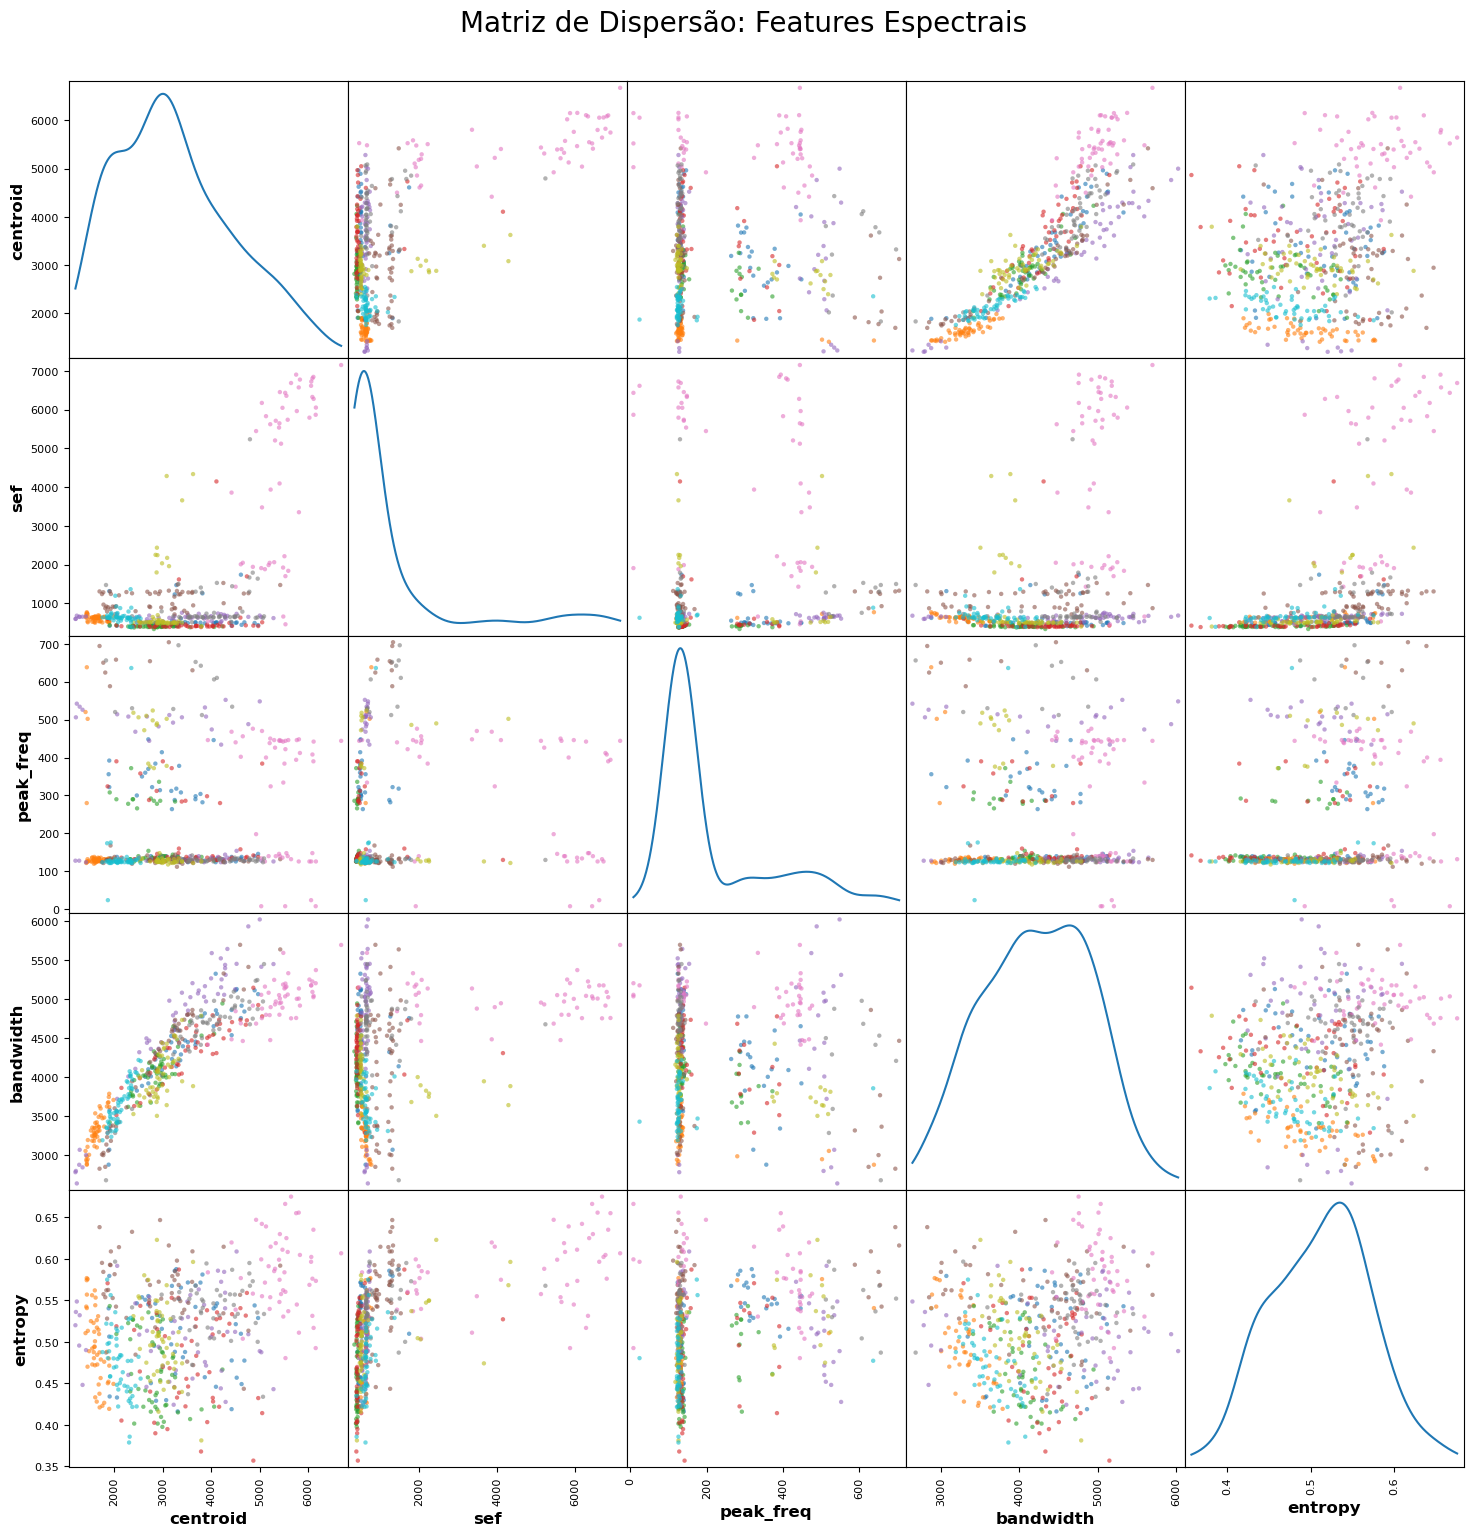

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
colunas=['centroid','sef','peak_freq','bandwidth','entropy']
df_plot=dados_df[colunas+['digito']]
axes=pd.plotting.scatter_matrix(
    df_plot[colunas],
    c=df_plot['digito'],
    cmap='tab10',
    alpha=0.6,
    figsize=(18,18),
    diagonal='kde',
    s=40,
    linewidth=0.5
)
n=len(colunas)
for i in range(n):
    for j in range(n):
        if i==n-1:
            axes[i,j].set_xlabel(colunas[j],fontsize=12,fontweight='bold')
        if j==0:
            axes[i,j].set_ylabel(colunas[i],fontsize=12,fontweight='bold')
plt.suptitle('Matriz de Dispersão: Features Espectrais',fontsize=20,y=0.92)
plt.show()

### As melhores três _features_ espectrais.
Eu dei prioridade a _plots_ onde existia pouca sobreposição de cores, logo máxima entropia (no sentido de informação).

Ao analisar os gráficos anteriores determinei que a maior quantia de informação estava em Centroids vs Entropy e Centroid vs. Bandwith.
Podemos assim determinar que estas três _features_, Centroids vs Entropy vs. Bandwith vão ter uma quantidade máxima de informação.

Podemos visualizar estas três _features_ no gráfico seguinte:

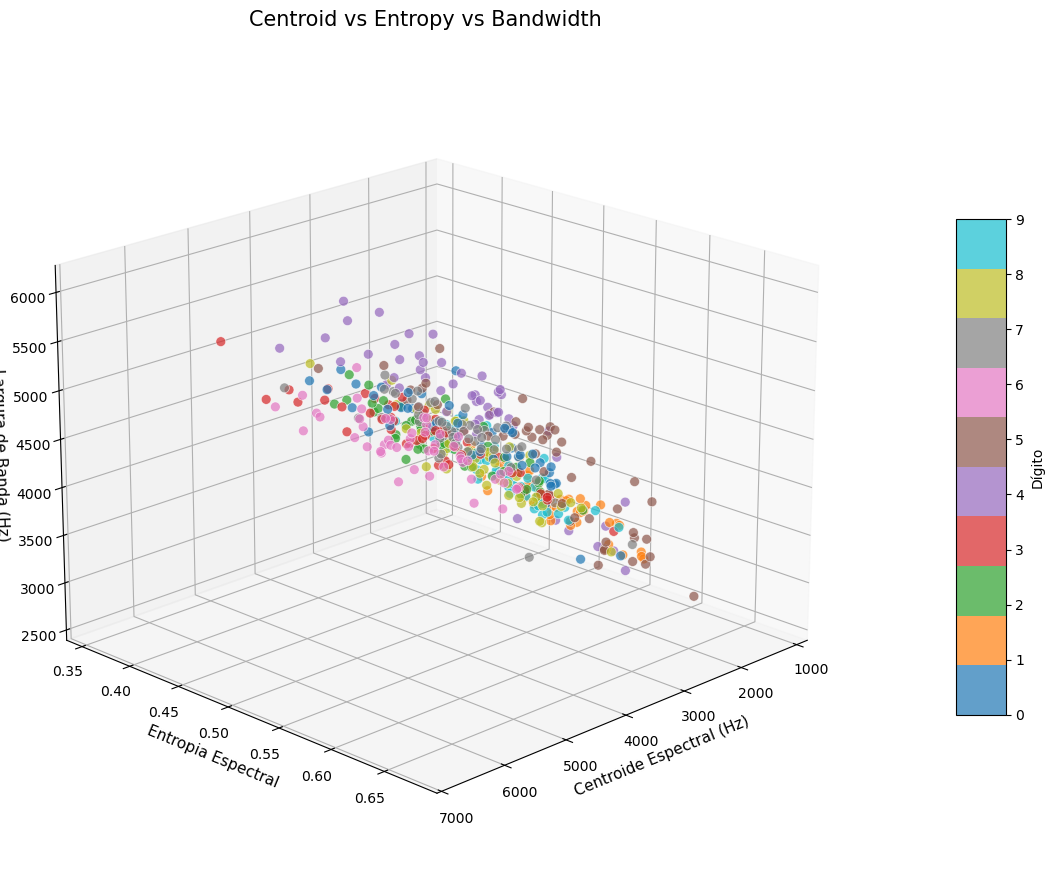

In [53]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
x = dados_df['centroid']
y = dados_df['entropy']
z = dados_df['bandwidth']
classes = dados_df['digito']
img = ax.scatter(x, y, z, c=classes, cmap='tab10', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)
ax.set_title('Centroid vs Entropy vs Bandwidth', fontsize=15, pad=20)
ax.set_xlabel('Centroide Espectral (Hz)', fontsize=11)
ax.set_ylabel('Entropia Espectral', fontsize=11)
ax.set_zlabel('Largura de Banda (Hz)', fontsize=11)
cbar = fig.colorbar(img, ax=ax, shrink=0.6, aspect=10, pad=0.1)
cbar.set_label('Dígito')
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

## Armazenamento dos dados importados (Ex. 13) 


 

In [67]:
"""
Remova da estrutura de dados criada no ponto 1 os sinais de áudio importados e guarde a estrutura 
de dados num ficheiro ‘.mat’ (passo importante para rapidamente carregar os dados no início da 
Meta 2). 
"""

df_meta2 = dados_df.drop(columns=['signal', 'signal_preproc'])
data_to_save = {col: df_meta2[col].values for col in df_meta2.columns}
data_to_save['scf_coefs'] = np.array(df_meta2['scf_coefs'].tolist())
filename = 'meta1.mat'
sio.savemat(filename, data_to_save)

print(f"Colunas exportadas: {list(data_to_save.keys())}")

Colunas exportadas: ['dir', 'nome', 'participante', 'digito', 'repeticao', 'sampling_rate', 'energia_curto', 'energia_longo', 'zcr', 'rms', 'duracao_ativa', 'scf_coefs', 'centroid', 'sef', 'peak_freq', 'bandwidth', 'entropy']
